# Chess Evaluations

References:
- Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data
- Python-chess: https://www.kaggle.com/code/wlifferth/part-1-understanding-python-chess-and-fen
- Chess FEN: https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split

import chess
from IPython.display import Math

In [2]:
from constants import *
from managers import DataManager, ChessManager, ModelManager, MetricsManager
from features import PieceInfo, PawnStructure, KingSafety, Mobility, Attackers, PositionalControl, GameInfo
from features import FEATURE_TRANSFORMERS

Our dataset is made of roughly 13 millions different games. However, to test our model we will be dealing with extremely smaller samples, to save on memory and time.

In [ ]:
dataframe = pd.read_csv(DATASET_FILE, nrows=5000)

In [ ]:
EXAMPLE_GAME_ID = 50
EXAMPLE_FEN = dataframe["FEN"][EXAMPLE_GAME_ID]
EXAMPLE_FEN_FIELDS = EXAMPLE_FEN.split(" ")

labels = ["A","B","C","D","E","F"]

parts = [
    rf"\underbrace{{ \text{{{field}}} }}_{{ {label} }}"
    for field, label in zip(EXAMPLE_FEN_FIELDS, labels)
]

board = chess.Board(dataframe["FEN"][EXAMPLE_GAME_ID])

# FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position.

A FEN record contains six fields, each separated by a space, e.g.:

In [ ]:
display(Math(r" \quad ".join(parts)))
display(board)

The fields are as follows:

- $A$: Piece placement
    - pawn = "P", knight = "N", bishop = "B", rook = "R", queen = "Q" and king = "K"
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.
- $B$: Active color: "w" for white to move, "b" for black
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
- $E$: Halfmove clock: number of halfmoves since the last capture or pawn advance (used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule))
- $F$: Fullmove number: number of the moves since the beginning of the game

this whole project is about feature engineering, so extracting features from the FEN, blablabla...

# Cleaning

The evaluation feature is a string that contains the [centipawn evaluation](https://chess.fandom.com/wiki/Centipawn), and in the case of forced checkmate in less than 22 moves (the engine's depth), a hashtag is included at the beginning together with the number of moves. This is an edge-case, which is of no interest for our current goals. Moreover, these cases represent less than 1% of the dataset, which is already big enough, so we can just eliminate these rows.

Source: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858

In [ ]:
dataframe[dataframe["Evaluation"].str[0] == "#"]

In [ ]:
dataframe = dataframe[~dataframe[EVAL].astype(str).str.contains("#")].copy()
dataframe[EVAL] = pd.to_numeric(dataframe[EVAL], errors="coerce").astype(int)

In [ ]:
display(dataframe.dtypes[EVAL])
display(sum(dataframe[EVAL].isna()))

We also see the evaluation has a vast range of values, but most of them are accumulated around zero.

In [ ]:
dataframe[EVAL].hist(bins=100)
plt.show()

So we want to either clip them to a maximum (say 1000) or consider them outliers and remove them from the training dataset. For now, we will consider the dataset clipped at 1000.

In [ ]:
dataframe[EVAL] = np.clip(dataframe[EVAL], -1000, 1000)

In [ ]:
dataframe[EVAL].hist(bins=100)
plt.show()

# Evaluation Cleaner

# Data Manager

The most important function from this class is apply_transformers, which develops the application of each transformer in our dataset, and updating only the features set (each transformer has to be defined before applying it). As we are just interested in the features, there is no need to accumulate the transformers, so we replace the last transformers for the new ones in every iteration. We make sure we only apply the transformer if its features are not already in the dataset.

In [ ]:
dm = DataManager(DATASET_FILE, sample_size=100_000, read_size=2_000_000, random_state=RANDOM_STATE)
DATAFRAME = dm.df
DATAFRAME.info(memory_usage="deep")
dm.df_all[EVAL].hist(bins=100)
plt.show()

# Chess Manager

In [ ]:
cm = ChessManager(dm)
cm.show(100)

From now on, we will be creating several classes to implement the feature engineering, with the object-oriented programming techniques, such as @staticmethod, wich is interesting if we want to be adding new functions in the future. The idea is to create a class with a "tranform" function whcih with the help of other functions also defined inside the class, it is feasible to update the Class' features and then apply the "apply_transformers" to the data model. Then, we will be analysing how does the model behave with upcoming metrics section, so that we can see the (expected) improvment provided by our feature engineering.

# Number of Pieces

Here we have the first class, which we believe provides a large part of the game information needed to predict the evidence. These are the foundations for building more complex features.

In [ ]:
dm.apply_transformers([PieceInfo])

# Model Manager

This class trains a model using the data manager and provides prediction methods, including generating a prediction from a given FEN string by preprocessing it to match the model’s input format.

In [ ]:
mm = ModelManager(GradientBoostingRegressor(), dm)
mm.fit()
mm.predict()
mm.predict_fen(fen=cm.dm.df.loc[EXAMPLE_GAME_ID, FEN])

# Metrics Manager

And for an already selected model, we will need a MetricsManager, which will compute different evaluation metrics and generate plots to analyze the model’s performance.

In [ ]:
metm = MetricsManager(mm)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()


# Basic Features

The most natural indicator that one would consider to predict the advantage of the players is the piece count: how many pieces does each player have. So, we code the first transformer to extract the piece count from the FEN.

Right away, we test our simple model with only these basic features. We will be considering a simple Random Forest and Linear Regressor.

Since the dataset is fairly balanced (54%-37), we will consider the plain sign accuracy of our prediction. For now, we are just checking the evaluation's sign because the RMSE is not yet a good indicator for model fitness.

## Piece values

Source: https://chess.fandom.com/wiki/Value

In [ ]:
PIECE_VALUATIONS = {
    "standard": {
        chess.PAWN: 100,
        chess.KNIGHT: 300,
        chess.BISHOP: 300,
        chess.ROOK: 500,
        chess.QUEEN: 900,
        chess.KING: 0
    },
    "Jacob Sarratt's": {
        chess.PAWN: 100,
        chess.KNIGHT: 462,
        chess.BISHOP: 487,
        chess.ROOK: 750,
        chess.QUEEN: 1187,
        chess.KING: 0
    }
}

In [ ]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## Number of Individual Piece Types

### Extracting Piece's Valuations

In [ ]:
mm_lr = ModelManager(LinearRegression(), dm)
mm_lr.fit()
mm_lr.predict()
metm.mm = mm_lr
metm.report()

In [ ]:
coefs = pd.Series(mm_lr.model.coef_, index=dm.X_train.columns)
intercept = mm_lr.model.intercept_
piece_types = ["Pawn","Knight","Bishop","Rook","Queen"]

avg_abs = {}
for p in piece_types:
    cols = [c for c in coefs.index if p in c]
    vals = coefs[cols].abs()
    avg_abs[p] = vals.mean()

avg_abs = pd.Series(avg_abs)

pawn_val = avg_abs["Pawn"]
queen_val = avg_abs["Queen"]

scale = (900 - 100) / (queen_val - pawn_val)
shift = 100 - pawn_val * scale

normalized = avg_abs * scale + shift
normalized

In this section, we have seen that our model has been gaining better results in the metrics. Even though this is a really premature conclusion, as there is not a Cross-Validation method, we started with a 0.8045 Centipawn ±200 accuracy and a 0.87 AUC and we arrived up to 0.824 Centipawn ±200 accuracy and a 0.88 AUC.

## Pawn Structure

In [ ]:
dm.apply_transformers([PawnStructure])

In [ ]:
dm.train_test_split(list(PawnStructure.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

In [ ]:
np.sum(mm.y_pred > 0) / len(mm.y_pred)

In [ ]:
np.sum(mm.dm.y_test > 0) / len(mm.y_pred)

In [ ]:
dm.train_test_split(["Passed_Pawns_White"])
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

En aquí podem veure que les mètriques del model tornen a baixar, com estaven amb el model comptant només el nombre de peces. 

## King Safety

In [ ]:
dm.apply_transformers([KingSafety])

In [ ]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

---

# FULL

In [12]:
dm = DataManager(
    filepath=DATASET_FILE,
    read_size=1_000_000,
    sample_size=500_000,
    transformers=FEATURE_TRANSFORMERS,
)

In [13]:
model = GradientBoostingRegressor(
    loss="huber",
    learning_rate=0.03,
    n_estimators=1000,
    max_depth=5,
    subsample=0.8,
    max_features="sqrt",
    random_state=42
)

mm_gb = ModelManager(model, dm)

In [14]:
mm_gb.fit()
mm_gb.predict()

array([ 46.70595535, 284.1676219 ,  69.39140349, ...,  52.80560745,
        48.38910283,  95.62961678], shape=(100000,))

MSE: 39218.269634584336
Sign accuracy: 0.67494
White winning recall: 0.8396016880136226
Black winning recall: 0.6369104146881924
Draw recall: 0.0
Centipawn ±200 accuracy: 0.81779
R2: 0.34735052838468483
R2 adjusted: 0.34700443727552976
Spearman rank correlation: 0.58752451664027


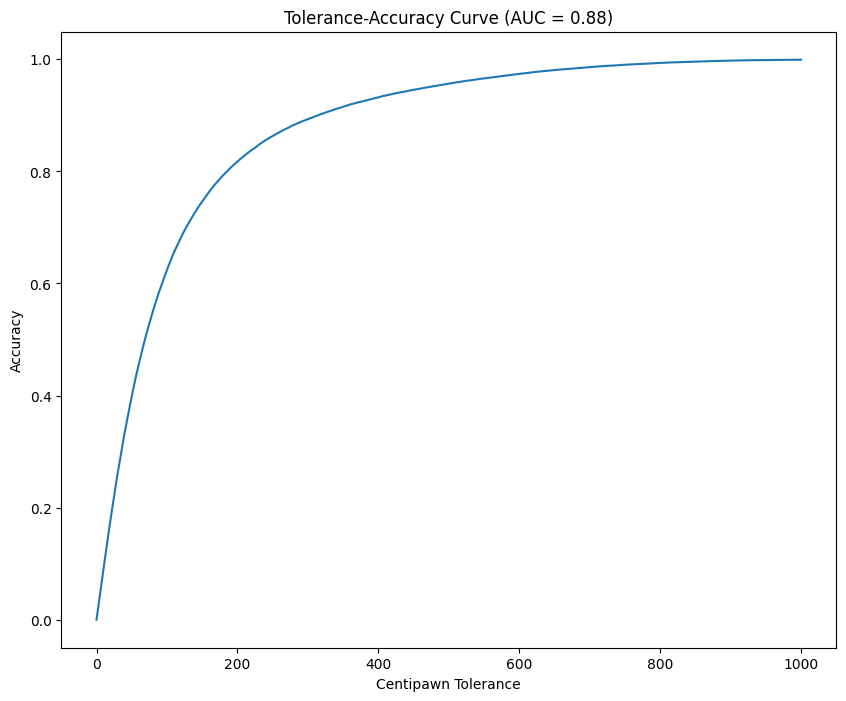

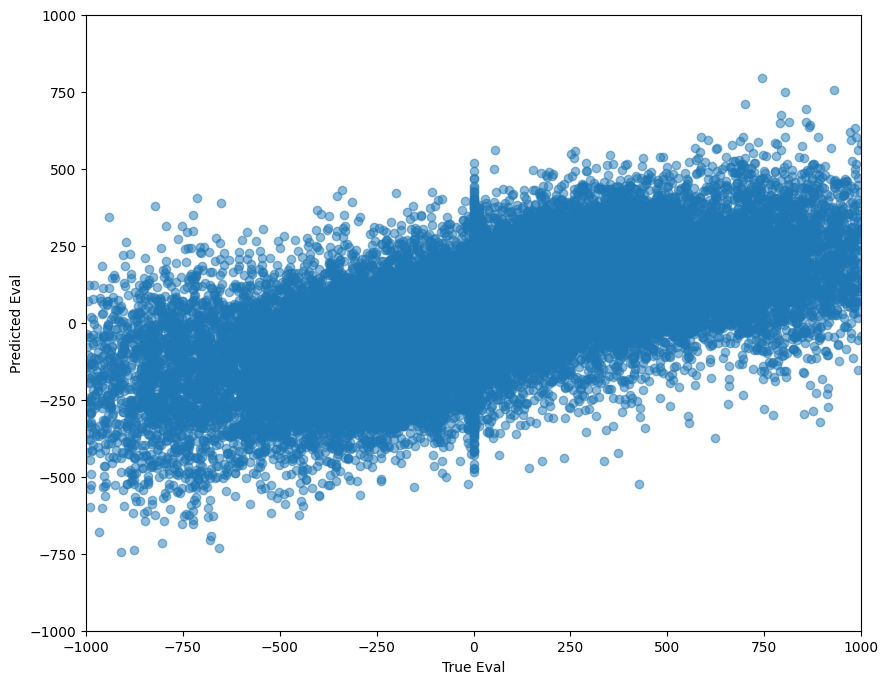

In [15]:
metm = MetricsManager(mm_gb)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

---

In [ ]:
# xat
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0
}

CENTRAL_SQUARES = {chess.E4, chess.D4, chess.E5, chess.D5}

def is_passed_pawn(board, square, color):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    if color == chess.WHITE:
        # any black pawn on same or adjacent file ahead (higher ranks)?
        for r in range(rank + 1, 8):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and not board.color_at(sq):
                        return False
        return True
    else:
        # black pawn: look for white pawns ahead (lower ranks)
        for r in range(rank - 1, -1, -1):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and board.color_at(sq):
                        return False
        return True

def pawn_stats(board, color):
    pawns = [sq for sq, piece in board.piece_map().items() if piece.piece_type == chess.PAWN and piece.color == color]
    files = {}
    doubled = 0
    isolated = 0
    passed = 0
    for sq in pawns:
        f = chess.square_file(sq)
        files.setdefault(f, 0)
        files[f] += 1
    doubled = sum(count - 1 for count in files.values() if count > 1)
    # isolated: file has pawns ==1 and no pawns on adjacent files
    for f, count in files.items():
        if count == 1 and files.get(f - 1, 0) == 0 and files.get(f + 1, 0) == 0:
            isolated += 1
    for sq in pawns:
        if is_passed_pawn(board, sq, color):
            passed += 1
    pawn_islands = 0
    sorted_files = sorted(files.keys())
    if sorted_files:
        prev = sorted_files[0] - 2
        for f in sorted_files:
            if f != prev + 1:
                pawn_islands += 1
            prev = f
    return {"doubled": doubled, "isolated": isolated, "passed": passed, "islands": pawn_islands}

def extract_features_from_fen(fen: str) -> dict:
    b = chess.Board(fen)
    features = {}
    # counts and material
    for color, prefix in ((chess.WHITE, "W_"), (chess.BLACK, "B_")):
        mat = 0.0
        for ptype in (chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING):
            cnt = len([1 for sq, pc in b.piece_map().items() if pc.piece_type == ptype and pc.color == color])
            features[f"{prefix}count_{ptype}"] = cnt
            mat += cnt * PIECE_VALUES[ptype]
        features[f"{prefix}material"] = mat
        # bishop pair
        features[f"{prefix}bishop_pair"] = int(features[f"{prefix}count_{chess.BISHOP}"] >= 2)
    # material diff and total
    features["mat_diff"] = features["W_material"] - features["B_material"]
    features["mat_total"] = features["W_material"] + features["B_material"]

    # mobility: legal moves for each side
    b_white = b.copy()
    b_white.turn = True
    features["mobility_white"] = len(list(b_white.legal_moves))
    b_black = b.copy()
    b_black.turn = False
    features["mobility_black"] = len(list(b_black.legal_moves))
    # mobility for side to move
    features["mobility_to_move"] = len(list(b.legal_moves))

    # king safety: attackers on king and in king zone
    wk_sq = b.king(chess.WHITE)
    bk_sq = b.king(chess.BLACK)
    features["W_king_attackers"] = 0 if wk_sq is None else len(b.attackers(chess.BLACK, wk_sq))
    features["B_king_attackers"] = 0 if bk_sq is None else len(b.attackers(chess.WHITE, bk_sq))
    # king zone attackers
    def king_zone_attackers(board, king_sq, attacker_color):
        if king_sq is None:
            return 0
        zone = [king_sq] + [n for n in chess.SQUARES if chess.square_distance(king_sq, n) == 1]
        return sum(len(board.attackers(attacker_color, sq)) for sq in zone)
    features["W_king_zone_attackers"] = king_zone_attackers(b, wk_sq, chess.BLACK)
    features["B_king_zone_attackers"] = king_zone_attackers(b, bk_sq, chess.WHITE)

    # pawn structure features
    pw = pawn_stats(b, chess.WHITE)
    pb = pawn_stats(b, chess.BLACK)
    for k, v in pw.items():
        features[f"W_pawn_{k}"] = v
    for k, v in pb.items():
        features[f"B_pawn_{k}"] = v

    # center control: attacks on central squares
    features["center_control_white"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.WHITE, sq))
    features["center_control_black"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.BLACK, sq))

    # central piece presence
    features["W_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.WHITE and sq in CENTRAL_SQUARES)
    features["B_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.BLACK and sq in CENTRAL_SQUARES)

    # castling rights and en-passant
    features["W_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.WHITE))
    features["W_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.WHITE))
    features["B_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.BLACK))
    features["B_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.BLACK))
    features["has_ep"] = int(b.ep_square is not None)
    features["in_check"] = int(b.is_check())

    # move counters / phase
    features["halfmove_clock"] = b.halfmove_clock
    features["fullmove_number"] = b.fullmove_number
    initial_total = sum(v * cnt for v, cnt in [
        (PIECE_VALUES[chess.PAWN], 16),
        (PIECE_VALUES[chess.KNIGHT], 4),
        (PIECE_VALUES[chess.BISHOP], 4),
        (PIECE_VALUES[chess.ROOK], 4),
        (PIECE_VALUES[chess.QUEEN], 2),
    ])
    features["phase"] = (features["mat_total"] / initial_total) if initial_total > 0 else 0.0

    # side to move
    features["side_to_move_white"] = int(b.turn)

    return features

rows = [extract_features_from_fen(fen) for fen in dm.df[FEN]]
X = pd.DataFrame(rows)
y = dm.df[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

dm2 = DataManager(DATASET_FILE, read_size=1, sample_size=1)
dm2.X_train, dm2.X_test, dm2.y_train, dm2.y_test = X_train, X_test, y_train, y_test
mm2 = ModelManager(GradientBoostingRegressor(), dm2)

In [ ]:
mm2.fit()
mm2.predict()

metm2 = MetricsManager(mm2)
metm2.report()
metm2.plot_tol_acc()
metm2.plot_scatter()

sampling from 15_000_000:

- Mean Squared Error: 47108.02274584996
- Sign accuracy: 0.67685
- Positive sign recall: 0.8400834677036897
- Negative sign recall: 0.6334596643205198
- Centipawn ±200 accuracy: 0.76635

sampling from 200_00:

- Mean Squared Error: 29028.021170256125
- Sign accuracy: 0.66445
- Positive sign recall: 0.8580901856763926
- Negative sign recall: 0.5744510338195223
- Centipawn ±200 accuracy: 0.863